# Compare inputs: Sensorium vs Mouse data

Visualize how **images** and **behavior** look when fed into the same CNN+shifter model from each dataset. Use this to debug why Sensorium training may show correlation not improving (or decreasing) while R²/MSE change — input distribution differences can push the model in different directions.

**Set paths below** if your Sensorium or mouse data live elsewhere.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, Subset
import os

# Paths (same as in training notebooks)
SENSORIUM_ROOT = "/home/herbelinluke/Downloads/dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20"
MOUSE_FILE_ID = "070921_J553RT"
MOUSE_VID_TYPE = "vid_mean"  # or vid_shift_mean
MOUSE_SEGMENT_NUM = 10

N_SAMPLES = 256   # how many samples to pull for stats (batch-like)
N_SHOW = 8       # number of example frames to show in grid

In [2]:
from mouse_model.sensorium_dataset import SensoriumDataset
from mouse_model.data_utils_new import MouseDatasetSegNewBehav

sensorium_available = os.path.isdir(SENSORIUM_ROOT)
if not sensorium_available:
    print("Sensorium not found at", SENSORIUM_ROOT, "-> will skip Sensorium plots. Set SENSORIUM_ROOT.")
else:
    ds_sens = SensoriumDataset(
        root_dir=SENSORIUM_ROOT,
        data_split="train",
        seq_len=1,
        standardize_responses=True,
        target_size=(60, 80),
    )
    print("Sensorium train size:", len(ds_sens), "num_neurons:", ds_sens.num_neurons)

# Mouse: same as train_cnn_shifter_mouse_vs_sensorium (one segment for speed, or concat)
ds_mouse_list = [
    MouseDatasetSegNewBehav(
        file_id=MOUSE_FILE_ID,
        segment_num=MOUSE_SEGMENT_NUM,
        seg_idx=i,
        data_split="train",
        vid_type=MOUSE_VID_TYPE,
        seq_len=1,
        predict_offset=1,
    )
    for i in range(MOUSE_SEGMENT_NUM)
]
ds_mouse = ConcatDataset(ds_mouse_list)
print("Mouse train size:", len(ds_mouse))

Sensorium train size: 348 num_neurons: 7863
Mouse train size: 37660


## Collect batches of (image, behav) from both datasets

We pull `N_SAMPLES` so we can compare distributions; images are (1, 1, 60, 80) or (1, 60, 80) depending on dataset.

In [3]:
def collect_batch(dataset, n_samples, name=""):
    n = min(n_samples, len(dataset))
    indices = np.linspace(0, len(dataset) - 1, n, dtype=int)
    images = []
    behaves = []
    for i in indices:
        img, beh, _ = dataset[i]
        if isinstance(img, np.ndarray):
            img = img
        else:
            img = img.numpy()
        if isinstance(beh, np.ndarray):
            beh = beh
        else:
            beh = beh.numpy()
        images.append(img)
        behaves.append(beh)
    images = np.concatenate(images, axis=0)
    behaves = np.concatenate(behaves, axis=0)
    return images, behaves

if sensorium_available:
    imgs_sens, beh_sens = collect_batch(ds_sens, N_SAMPLES, "Sensorium")
    print("Sensorium images shape:", imgs_sens.shape, "behav:", beh_sens.shape)

imgs_mouse, beh_mouse = collect_batch(ds_mouse, N_SAMPLES, "Mouse")
print("Mouse images shape:", imgs_mouse.shape, "behav:", beh_mouse.shape)

/home/herbelinluke/Documents/bioV/2023-Xu-Multimodal-Mouse-V1/mouse_model/sensorium_dataset.py:273: RuntimeWarning: Mean of empty slice
  frame = np.nanmean(vid, axis=0) if self.vid_frame == "mean" else vid[vid.shape[0] // 2]


Sensorium images shape: (256, 1, 60, 80) behav: (256, 6)
Mouse images shape: (256, 1, 60, 80) behav: (256, 6)


## 1. Example frames (first N_SHOW samples)

Top row: Sensorium. Bottom row: Mouse. Same model sees these as (1, 60, 80) or (1, 1, 60, 80).

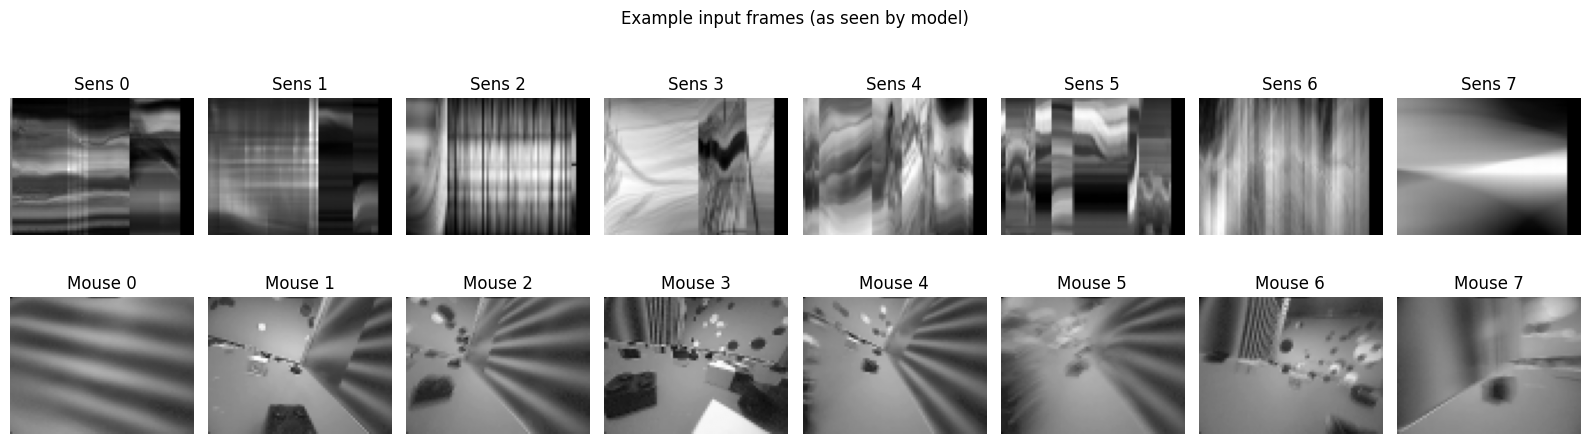

In [4]:
def to_frame(x):
    """(C, H, W) or (1, C, H, W) -> (H, W)."""
    x = np.squeeze(x)
    if x.ndim == 3:
        x = x[0]
    return x

n_show = min(N_SHOW, len(imgs_mouse))
if sensorium_available:
    n_show_sens = min(N_SHOW, len(imgs_sens))
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
    if n_show == 1:
        axes = axes.reshape(2, 1)
    for j in range(n_show_sens):
        axes[0, j].imshow(to_frame(imgs_sens[j]), cmap="gray", vmin=0, vmax=1)
        axes[0, j].set_title("Sens {}".format(j))
        axes[0, j].axis("off")
    for j in range(n_show):
        axes[1, j].imshow(to_frame(imgs_mouse[j]), cmap="gray", vmin=0, vmax=1)
        axes[1, j].set_title("Mouse {}".format(j))
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("Sensorium")
    axes[1, 0].set_ylabel("Mouse")
else:
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
    if n_show == 1:
        axes = [axes]
    for j in range(n_show):
        axes[j].imshow(to_frame(imgs_mouse[j]), cmap="gray", vmin=0, vmax=1)
        axes[j].set_title("Mouse {}".format(j))
        axes[j].axis("off")
plt.suptitle("Example input frames (as seen by model)")
plt.tight_layout()
plt.show()

## 2. Pixel value distribution (all pixels in batch)

Mouse normalizes **per segment** (one min/max for whole segment → global [0,1]). Sensorium normalizes **per frame** (each image min-max → [0,1]). So Mouse can have more variation in absolute brightness across samples; Sensorium every frame is [0,1] by construction.

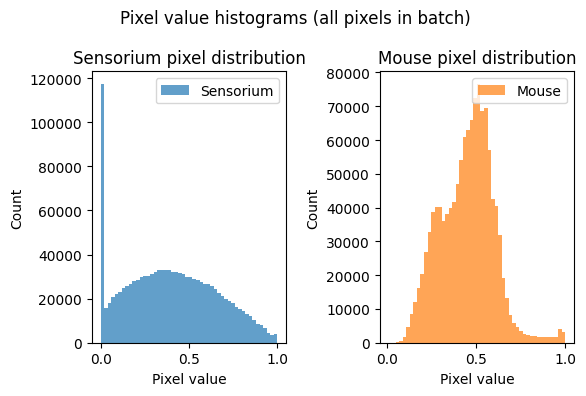

In [5]:
fig, axes = plt.subplots(1, 2 if sensorium_available else 1, figsize=(6 if sensorium_available else 5, 4))
if not sensorium_available:
    axes = [axes]

def flatten_pixels(imgs):
    return np.squeeze(imgs).reshape(-1)

if sensorium_available:
    axes[0].hist(flatten_pixels(imgs_sens), bins=50, range=(0, 1), color="C0", alpha=0.7, label="Sensorium")
    axes[0].set_xlabel("Pixel value")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Sensorium pixel distribution")
    axes[0].legend()

axes[-1].hist(flatten_pixels(imgs_mouse), bins=50, color="C1", alpha=0.7, label="Mouse")
axes[-1].set_xlabel("Pixel value")
axes[-1].set_ylabel("Count")
axes[-1].set_title("Mouse pixel distribution" if sensorium_available else "Mouse pixel distribution")
axes[-1].legend()

if sensorium_available:
    plt.suptitle("Pixel value histograms (all pixels in batch)")
plt.tight_layout()
plt.show()

## 3. Per-image statistics (min, max, mean per frame)

Reveals whether **contrast/brightness** differs sample-to-sample: Sensorium (per-frame norm) → each image min≈0, max≈1. Mouse (segment norm) → min/max can vary across samples.

In [6]:
# Collect batches of neural responses from each dataset

def collect_responses(dataset, n_samples, name=""):
    n = min(n_samples, len(dataset))
    indices = np.linspace(0, len(dataset) - 1, n, dtype=int)
    resps = []
    for i in indices:
        _, _, r = dataset[i]
        if isinstance(r, np.ndarray):
            r = r
        else:
            r = r.numpy()
        resps.append(r)
    # Stack so we get shape (samples, neurons, ...), not a single long 1D vector
    resps = np.stack(resps, axis=0)
    # Flatten everything except the sample dimension so shape is (samples, neurons)
    if resps.ndim > 2:
        resps = resps.reshape(resps.shape[0], -1)
    return resps

resp_sens = None
if sensorium_available:
    resp_sens = collect_responses(ds_sens, N_SAMPLES, "Sensorium")
    print("Sensorium responses shape:", resp_sens.shape)

resp_mouse = collect_responses(ds_mouse, N_SAMPLES, "Mouse")
print("Mouse responses shape:", resp_mouse.shape)

Sensorium responses shape: (256, 7863)
Mouse responses shape: (256, 68)


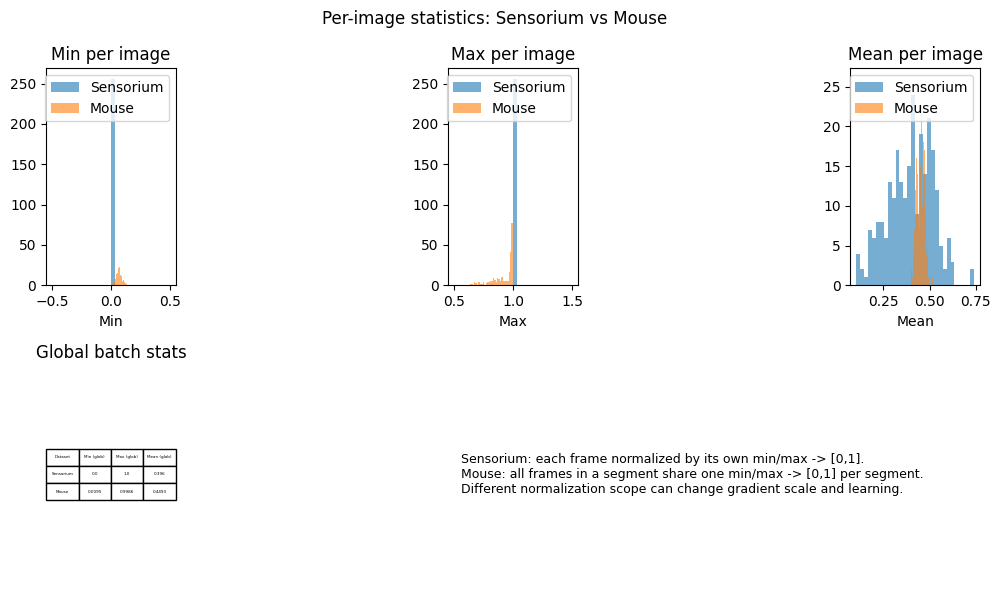

In [7]:
def per_image_stats(imgs):
    flat = np.squeeze(imgs)
    if flat.ndim == 3:
        n, h, w = flat.shape
        mins = flat.reshape(n, -1).min(axis=1)
        maxs = flat.reshape(n, -1).max(axis=1)
        means = flat.reshape(n, -1).mean(axis=1)
    else:
        n = flat.shape[0]
        mins = flat.reshape(n, -1).min(axis=1)
        maxs = flat.reshape(n, -1).max(axis=1)
        means = flat.reshape(n, -1).mean(axis=1)
    return mins, maxs, means

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
ax = axes[0, 0]
ax.set_title("Min per image")
if sensorium_available:
    m_s = per_image_stats(imgs_sens)
    ax.hist(m_s[0], bins=30, alpha=0.6, label="Sensorium", color="C0")
m_m = per_image_stats(imgs_mouse)
ax.hist(m_m[0], bins=30, alpha=0.6, label="Mouse", color="C1")
ax.legend()
ax.set_xlabel("Min")

ax = axes[0, 1]
ax.set_title("Max per image")
if sensorium_available:
    ax.hist(m_s[1], bins=30, alpha=0.6, label="Sensorium", color="C0")
ax.hist(m_m[1], bins=30, alpha=0.6, label="Mouse", color="C1")
ax.legend()
ax.set_xlabel("Max")

ax = axes[0, 2]
ax.set_title("Mean per image")
if sensorium_available:
    ax.hist(m_s[2], bins=30, alpha=0.6, label="Sensorium", color="C0")
ax.hist(m_m[2], bins=30, alpha=0.6, label="Mouse", color="C1")
ax.legend()
ax.set_xlabel("Mean")

# Summary table
ax = axes[1, 0]
ax.axis("off")
rows = [("Dataset", "Min (glob)", "Max (glob)", "Mean (glob)")]
if sensorium_available:
    rows.append(("Sensorium", np.round(imgs_sens.min(), 4), np.round(imgs_sens.max(), 4), np.round(imgs_sens.mean(), 4)))
rows.append(("Mouse", np.round(imgs_mouse.min(), 4), np.round(imgs_mouse.max(), 4), np.round(imgs_mouse.mean(), 4)))
ax.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="center")
ax.set_title("Global batch stats")

ax = axes[1, 1]
ax.axis("off")
txt = (
    "Sensorium: each frame normalized by its own min/max -> [0,1].\n"
    "Mouse: all frames in a segment share one min/max -> [0,1] per segment.\n"
    "Different normalization scope can change gradient scale and learning."
)
ax.text(0.1, 0.5, txt, transform=ax.transAxes, fontsize=9, verticalalignment="center", wrap=True)

axes[1, 2].axis("off")
plt.suptitle("Per-image statistics: Sensorium vs Mouse")
plt.tight_layout()
plt.show()

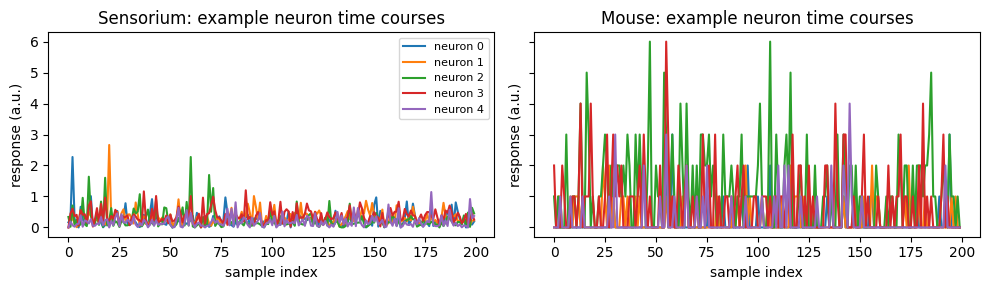

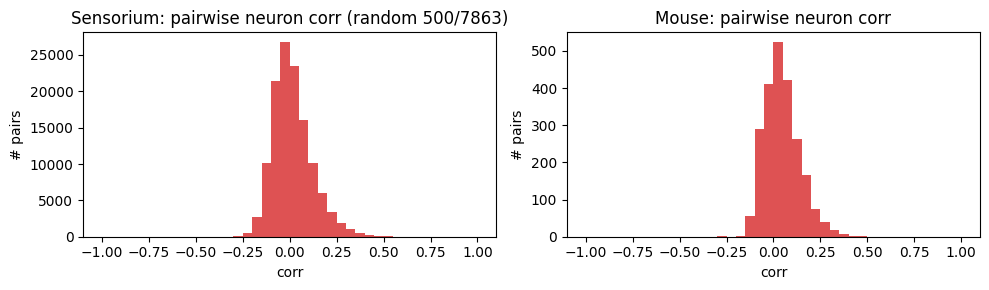

In [8]:
# Example neuron time-courses and pairwise correlation structure

def plot_example_traces(resp, name, ax, n_neurons=5, max_time=200):
    if resp is None:
        return
    n_samples, n_neurons_total = resp.shape
    t = np.arange(min(n_samples, max_time))
    n_show = min(n_neurons, n_neurons_total)
    for k in range(n_show):
        ax.plot(t, resp[: len(t), k], label=f"neuron {k}")
    ax.set_title(f"{name}: example neuron time courses")
    ax.set_xlabel("sample index")
    ax.set_ylabel("response (a.u.)")

fig, axes = plt.subplots(1, 2 if sensorium_available else 1, figsize=(10, 3), sharey=True)
if not sensorium_available:
    axes = [axes]

idx = 0
if sensorium_available and resp_sens is not None:
    plot_example_traces(resp_sens, "Sensorium", axes[idx])
    idx += 1

plot_example_traces(resp_mouse, "Mouse", axes[idx])

# Add a single legend (from the last axes that has lines)
axes[0].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Optional: look at distribution of pairwise neuron correlations

MAX_NEURONS_CORR = 500  # cap to avoid huge correlation matrix with 7863 neurons

def plot_corr_hist(resp, name, ax):
    if resp is None:
        return
    n_neurons = resp.shape[1]
    if n_neurons > MAX_NEURONS_CORR:
        idx = np.random.RandomState(0).choice(n_neurons, MAX_NEURONS_CORR, replace=False)
        resp_sub = resp[:, idx]
        subtitle = f" (random {MAX_NEURONS_CORR}/{n_neurons})"
    else:
        resp_sub = resp
        subtitle = ""
    corr = np.corrcoef(resp_sub.T)
    iu = np.triu_indices_from(corr, k=1)
    vals = corr[iu]
    ax.hist(vals, bins=40, range=(-1, 1), color="C3", alpha=0.8)
    ax.set_title(f"{name}: pairwise neuron corr{subtitle}")
    ax.set_xlabel("corr")
    ax.set_ylabel("# pairs")

fig, axes = plt.subplots(1, 2 if sensorium_available else 1, figsize=(10, 3))
if not sensorium_available:
    axes = [axes]

idx = 0
if sensorium_available and resp_sens is not None:
    plot_corr_hist(resp_sens, "Sensorium", axes[idx])
    idx += 1

plot_corr_hist(resp_mouse, "Mouse", axes[idx])

plt.tight_layout()
plt.show()

## 4. Behavior vectors (6-dim: speed, pitch, roll, phi, theta, eyerad)

The shifter uses (theta, phi, pitch, roll) = behav indices (4,3,1,2). Sensorium fills pitch/roll with 0 and uses pupil_center for phi/theta; Mouse has real head/eye data. Different scales can affect the shifter.

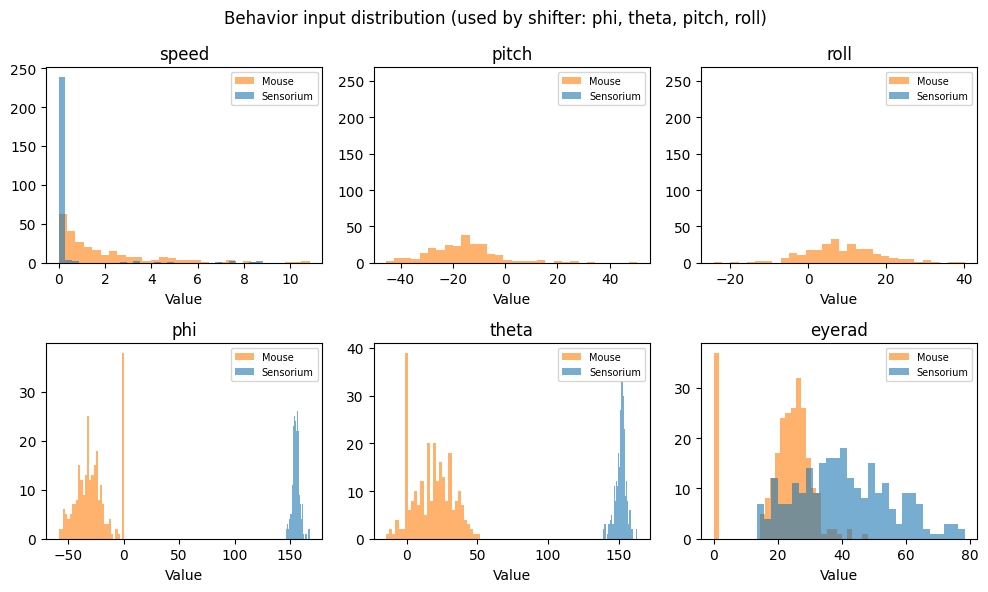

In [9]:
behav_labels = ["speed", "pitch", "roll", "phi", "theta", "eyerad"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()
for dim in range(6):
    ax = axes[dim]
    # behav shape can be (seq_len, 6) -> take first row
    if beh_mouse.ndim == 3:
        b_mouse = beh_mouse[:, 0, dim]
    else:
        b_mouse = beh_mouse[:, dim]
    ax.hist(b_mouse, bins=30, alpha=0.6, label="Mouse", color="C1")
    if sensorium_available:
        if beh_sens.ndim == 3:
            b_sens = beh_sens[:, 0, dim]
        else:
            b_sens = beh_sens[:, dim]
        ax.hist(b_sens, bins=30, alpha=0.6, label="Sensorium", color="C0")
    ax.set_title(behav_labels[dim])
    ax.legend(fontsize=7)
    ax.set_xlabel("Value")
plt.suptitle("Behavior input distribution (used by shifter: phi, theta, pitch, roll)")
plt.tight_layout()
plt.show()

## 5. Side-by-side global comparison

Single plot: mean image (average over batch) for Sensorium vs Mouse. If one dataset is systematically darker/brighter or has different spatial structure, it shows up here.

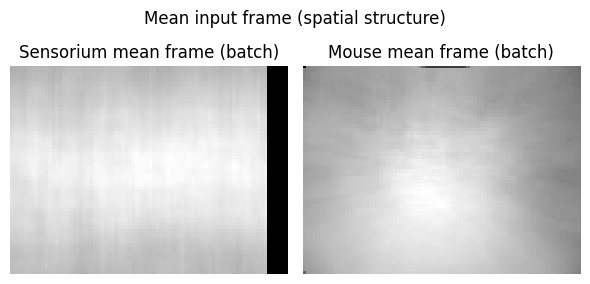

In [10]:
fig, axes = plt.subplots(1, 2 if sensorium_available else 1, figsize=(6 if sensorium_available else 5, 3))
if not sensorium_available:
    axes = [axes]

if sensorium_available:
    mean_sens = np.squeeze(imgs_sens).mean(axis=0)
    axes[0].imshow(mean_sens, cmap="gray")
    axes[0].set_title("Sensorium mean frame (batch)")
    axes[0].axis("off")

mean_mouse = np.squeeze(imgs_mouse).mean(axis=0)
axes[-1].imshow(mean_mouse, cmap="gray")
axes[-1].set_title("Mouse mean frame (batch)")
axes[-1].axis("off")
plt.suptitle("Mean input frame (spatial structure)")
plt.tight_layout()
plt.show()

## 6. Mean-frame vs Per-frame: what the CNN sees

The Sensorium dataset stores **36 video frames** per trial alongside **7863 neurons × 324 time bins** of neural responses (and 2 × 324 behavior time bins).

Two training modes feed different inputs to the CNN:

| Mode | Image input | Response target | Samples per trial |
|------|------------|-----------------|-------------------|
| **`vid_frame="mean"`** | Average of all 36 frames → 1 mean image | Average of all 324 time bins per neuron → 1 vector (7863,) | 1 |
| **`vid_frame="per_frame"`** | Each of the 36 frames individually | Average of ~9 time bins per frame per neuron → 1 vector (7863,) | 36 |

Below we visualize one trial to show the difference.

In [11]:
from mouse_model.sensorium_dataset import (
    normalize_movie, resize_video_frame, _bin_responses_to_frames,
)

TRIAL_ID = 0  # which trial to visualize

raw_vid = np.load(os.path.join(SENSORIUM_ROOT, "data", "videos", f"{TRIAL_ID}.npy"))  # (36, 64, 324)
raw_resp = np.load(os.path.join(SENSORIUM_ROOT, "data", "responses", f"{TRIAL_ID}.npy"))  # (7863, 324)

n_frames, h_raw, w_raw = raw_vid.shape
n_neurons, n_tbins = raw_resp.shape

print(f"Trial {TRIAL_ID}:")
print(f"  Video:     {raw_vid.shape}  → {n_frames} frames, {h_raw}×{w_raw} (H×W)")
print(f"  Responses: {raw_resp.shape} → {n_neurons} neurons, {n_tbins} time bins")
print(f"  Time bins per frame: {n_tbins / n_frames:.1f}")

# ---------- Prepare the two modes ----------

# MODE A: mean frame (single image averaged across all 36 frames)
mean_frame_raw = np.nanmean(raw_vid, axis=0)  # (64, 324)
mean_frame = resize_video_frame(mean_frame_raw, (60, 80))
mean_frame = normalize_movie(mean_frame)
mean_frame = np.nan_to_num(mean_frame, nan=0.0)
mean_frame = np.clip(mean_frame, 0.0, 1.0)

# Mean response: average across time (axis=1) → (7863,)
mean_resp = np.nanmean(raw_resp, axis=1)

# MODE B: per-frame (36 separate images, each with binned responses)
per_frames = []
for f in range(n_frames):
    fr = resize_video_frame(raw_vid[f], (60, 80))
    fr = normalize_movie(fr)
    fr = np.nan_to_num(fr, nan=0.0)
    per_frames.append(np.clip(fr, 0.0, 1.0))
per_frames = np.array(per_frames)  # (36, 60, 80)

# Bin responses: transpose to (T=324, N=7863), bin into (36, 7863)
binned_resp = _bin_responses_to_frames(raw_resp.T, n_frames)  # (36, 7863)

print(f"\nMean-frame mode:  1 image (60×80), 1 response vector ({mean_resp.shape[0]},)")
print(f"Per-frame mode:  {n_frames} images (60×80), {n_frames} response vectors ({binned_resp.shape[1]},)")

Trial 0:
  Video:     (36, 64, 324)  → 36 frames, 64×324 (H×W)
  Responses: (7863, 324) → 7863 neurons, 324 time bins
  Time bins per frame: 9.0

Mean-frame mode:  1 image (60×80), 1 response vector (7863,)
Per-frame mode:  36 images (60×80), 36 response vectors (7863,)


/tmp/ipykernel_26314/1898206719.py:21: RuntimeWarning: Mean of empty slice
  mean_frame_raw = np.nanmean(raw_vid, axis=0)  # (64, 324)
/home/herbelinluke/Documents/bioV/2023-Xu-Multimodal-Mouse-V1/mouse_model/sensorium_dataset.py:59: RuntimeWarning: Mean of empty slice
  out[f] = np.nanmean(resp[start:end], axis=0)


/tmp/ipykernel_26314/2603267401.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.0, 1, 0.97])


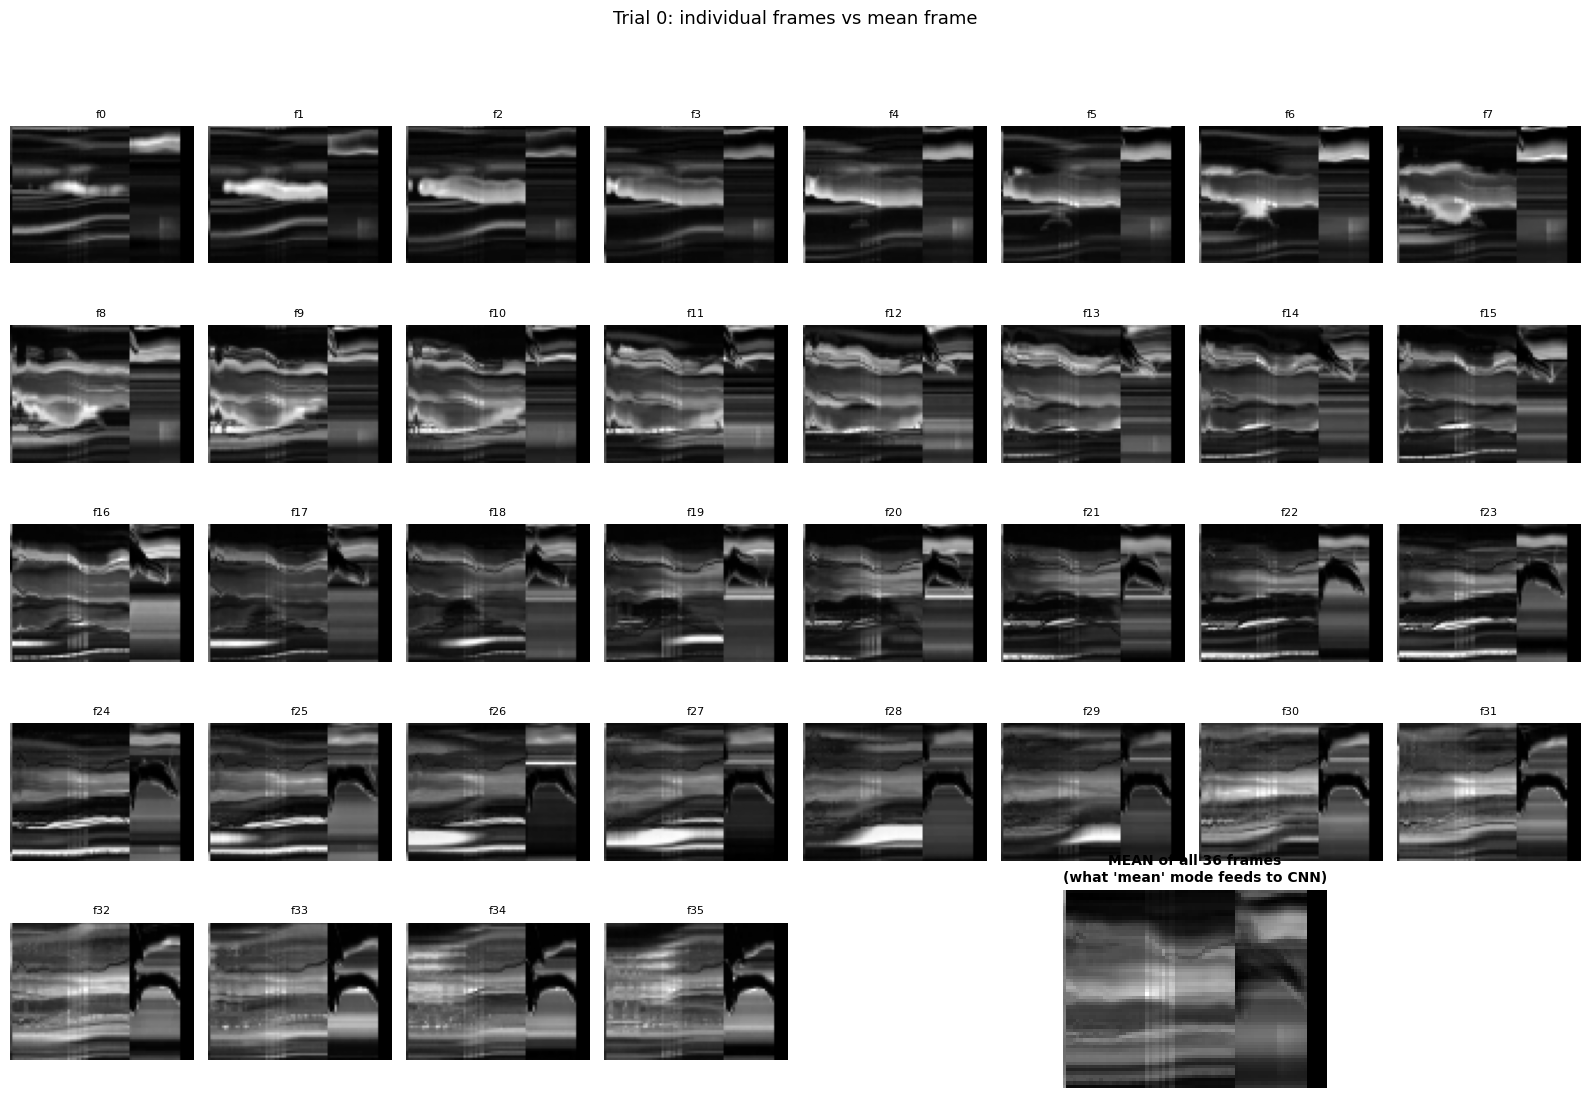

In [12]:
# --- Figure 1: All 36 video frames + the mean frame ---

fig, axes = plt.subplots(5, 8, figsize=(16, 11))

# First 4 rows × 8 cols = 32 slots for the 36 individual frames
# Put remaining 4 frames in row 5, then use the last 4 slots for the mean frame comparison
frame_axes = [axes[r][c] for r in range(4) for c in range(8)]  # 32 slots
extra_axes = [axes[4][c] for c in range(8)]

# Show all 36 individual frames
for f in range(n_frames):
    ax = frame_axes[f] if f < 32 else extra_axes[f - 32]
    ax.imshow(per_frames[f], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"f{f}", fontsize=8)
    ax.axis("off")

# Blank out unused frame slots in the grid (frames 32-35 are in extra row)
for f in range(n_frames, 32):
    frame_axes[f].axis("off")

# Last slots in row 5: show the mean frame prominently
# frames 32-35 occupy extra_axes[0:4], mean frame goes in extra_axes[4:8]
for i in range(4, 8):
    extra_axes[i].axis("off")

# Overlay mean frame spanning the remaining space
ax_mean = fig.add_axes([0.56, 0.02, 0.38, 0.18])  # [left, bottom, width, height]
ax_mean.imshow(mean_frame, cmap="gray", vmin=0, vmax=1)
ax_mean.set_title("MEAN of all 36 frames\n(what 'mean' mode feeds to CNN)", fontsize=10, fontweight="bold")
ax_mean.axis("off")

fig.suptitle(f"Trial {TRIAL_ID}: individual frames vs mean frame", fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0.0, 1, 0.97])
plt.show()

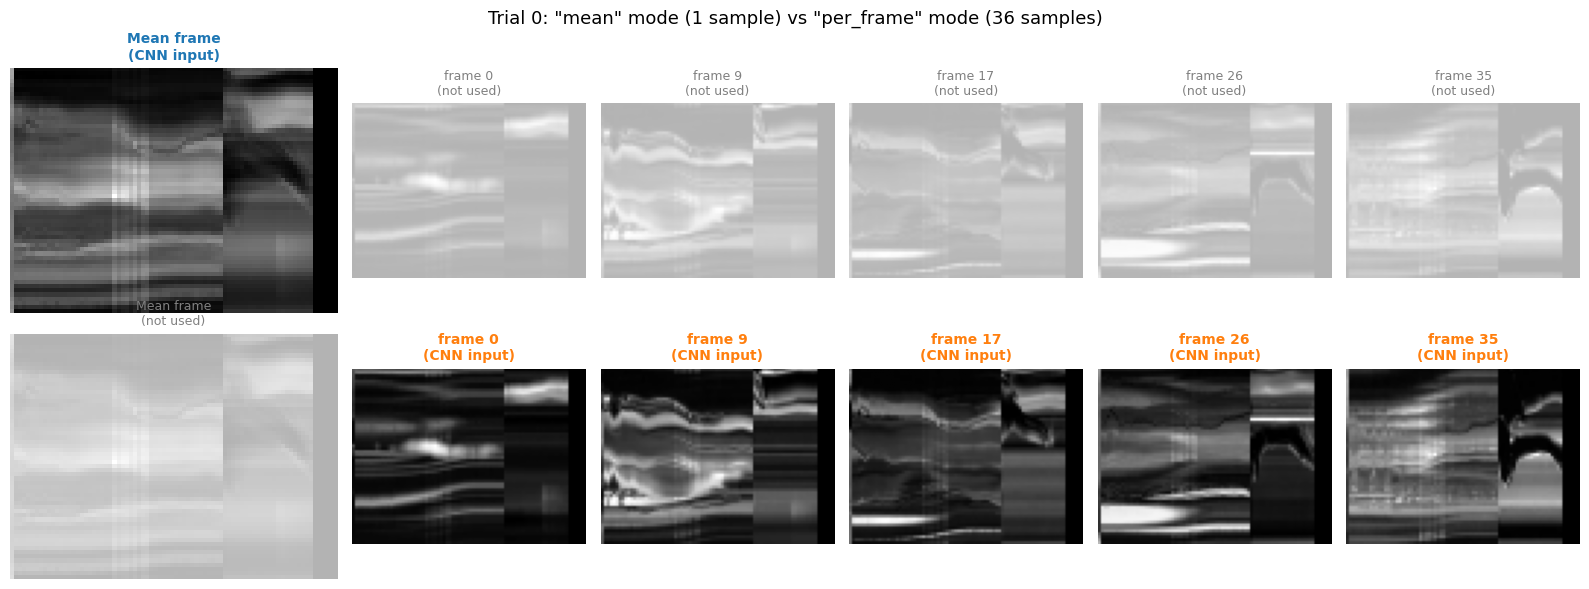

In [13]:
# --- Figure 2: Side-by-side comparison of the two modes ---
# Left: what "mean" mode sees (1 blurry averaged image)
# Right: what "per_frame" mode sees (sharp individual frames)

highlight_frames = [0, 9, 17, 26, 35]  # evenly spaced across the 36 frames

fig, axes = plt.subplots(2, len(highlight_frames) + 1, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [1.4] + [1] * len(highlight_frames)})

# Top row: MEAN mode
axes[0, 0].imshow(mean_frame, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Mean frame\n(CNN input)", fontsize=10, fontweight="bold", color="C0")
axes[0, 0].set_ylabel('vid_frame = "mean"', fontsize=11, fontweight="bold", color="C0")
axes[0, 0].axis("off")
for j, f in enumerate(highlight_frames):
    axes[0, j + 1].imshow(per_frames[f], cmap="gray", vmin=0, vmax=1, alpha=0.3)
    axes[0, j + 1].set_title(f"frame {f}\n(not used)", fontsize=9, color="gray")
    axes[0, j + 1].axis("off")

# Bottom row: PER_FRAME mode
axes[1, 0].imshow(mean_frame, cmap="gray", vmin=0, vmax=1, alpha=0.3)
axes[1, 0].set_title("Mean frame\n(not used)", fontsize=9, color="gray")
axes[1, 0].set_ylabel('vid_frame = "per_frame"', fontsize=11, fontweight="bold", color="C1")
axes[1, 0].axis("off")
for j, f in enumerate(highlight_frames):
    axes[1, j + 1].imshow(per_frames[f], cmap="gray", vmin=0, vmax=1)
    axes[1, j + 1].set_title(f"frame {f}\n(CNN input)", fontsize=10, fontweight="bold", color="C1")
    axes[1, j + 1].axis("off")

fig.suptitle(f'Trial {TRIAL_ID}: "mean" mode (1 sample) vs "per_frame" mode ({n_frames} samples)',
             fontsize=13)
plt.tight_layout()
plt.show()

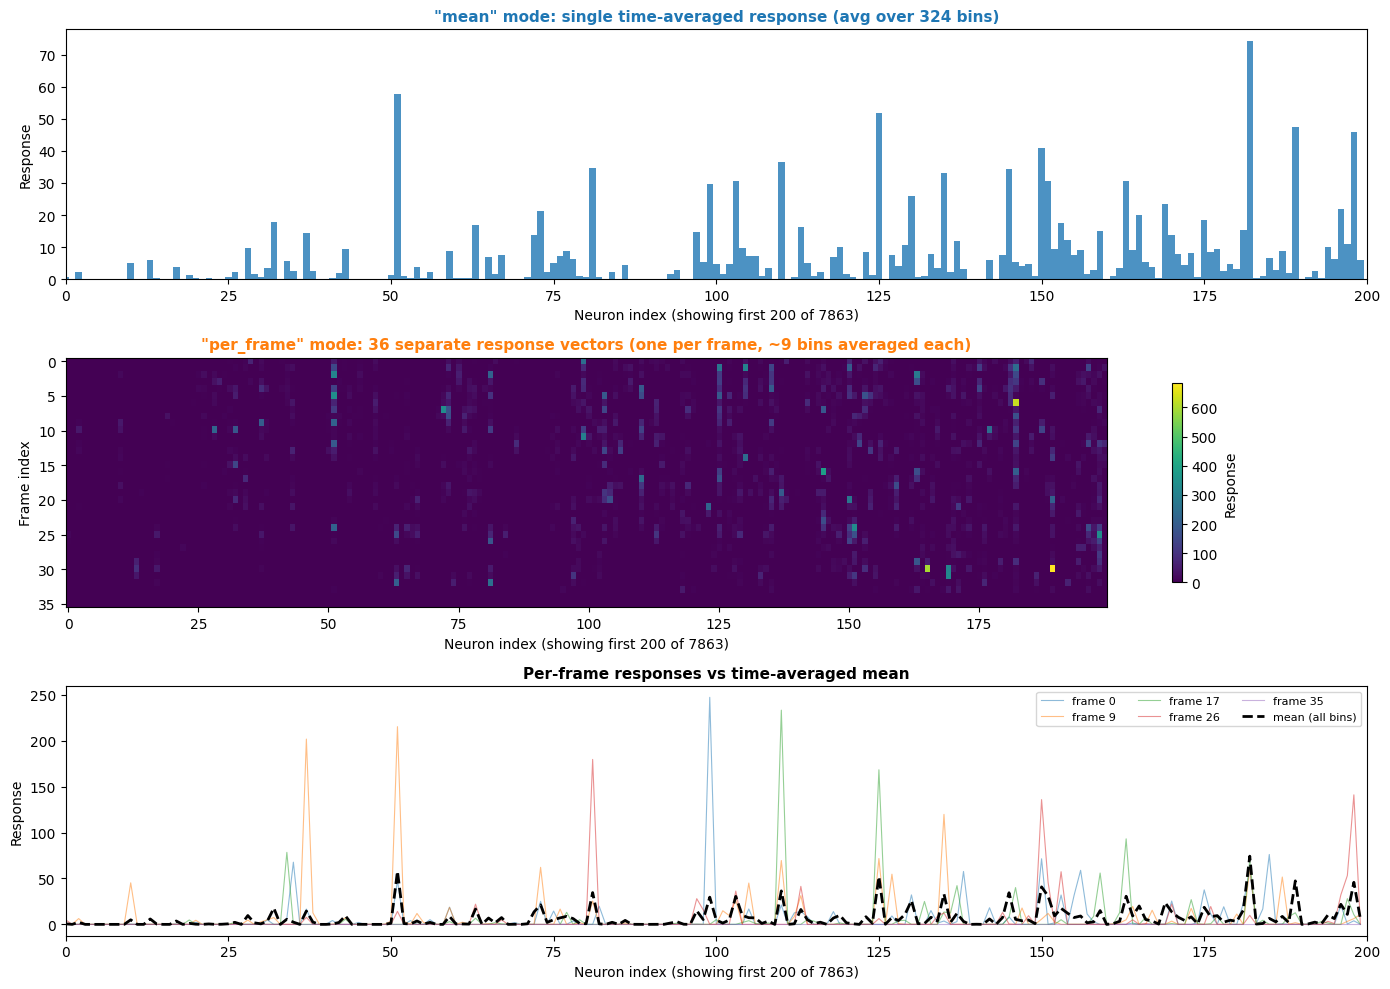

In [14]:
# --- Figure 3: Neural response comparison ---
# Show how the 7863-neuron response vector differs between the two modes

# Pick a subset of neurons to visualize (first 200 for readability)
N_VIS = 200
neuron_slice = slice(0, N_VIS)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel A: Mean response (single vector)
ax = axes[0]
ax.bar(np.arange(N_VIS), np.nan_to_num(mean_resp[neuron_slice]), width=1.0, color="C0", alpha=0.8)
ax.set_title(f'"mean" mode: single time-averaged response (avg over {n_tbins} bins)',
             fontsize=11, fontweight="bold", color="C0")
ax.set_ylabel("Response")
ax.set_xlim(0, N_VIS)
ax.set_xlabel(f"Neuron index (showing first {N_VIS} of {n_neurons})")

# Panel B: Per-frame responses as heatmap
ax = axes[1]
im = ax.imshow(np.nan_to_num(binned_resp[:, neuron_slice]), aspect="auto",
               cmap="viridis", interpolation="nearest")
ax.set_title(f'"per_frame" mode: {n_frames} separate response vectors (one per frame, ~9 bins averaged each)',
             fontsize=11, fontweight="bold", color="C1")
ax.set_ylabel("Frame index")
ax.set_xlabel(f"Neuron index (showing first {N_VIS} of {n_neurons})")
ax.set_yticks(np.arange(0, n_frames, 5))
plt.colorbar(im, ax=ax, label="Response", shrink=0.8)

# Panel C: Overlay a few per-frame vectors vs the mean
ax = axes[2]
for f in highlight_frames:
    ax.plot(np.arange(N_VIS), np.nan_to_num(binned_resp[f, neuron_slice]),
            alpha=0.5, linewidth=0.8, label=f"frame {f}")
ax.plot(np.arange(N_VIS), np.nan_to_num(mean_resp[neuron_slice]),
        color="black", linewidth=2.0, linestyle="--", label="mean (all bins)")
ax.set_title("Per-frame responses vs time-averaged mean", fontsize=11, fontweight="bold")
ax.set_ylabel("Response")
ax.set_xlabel(f"Neuron index (showing first {N_VIS} of {n_neurons})")
ax.set_xlim(0, N_VIS)
ax.legend(loc="upper right", fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

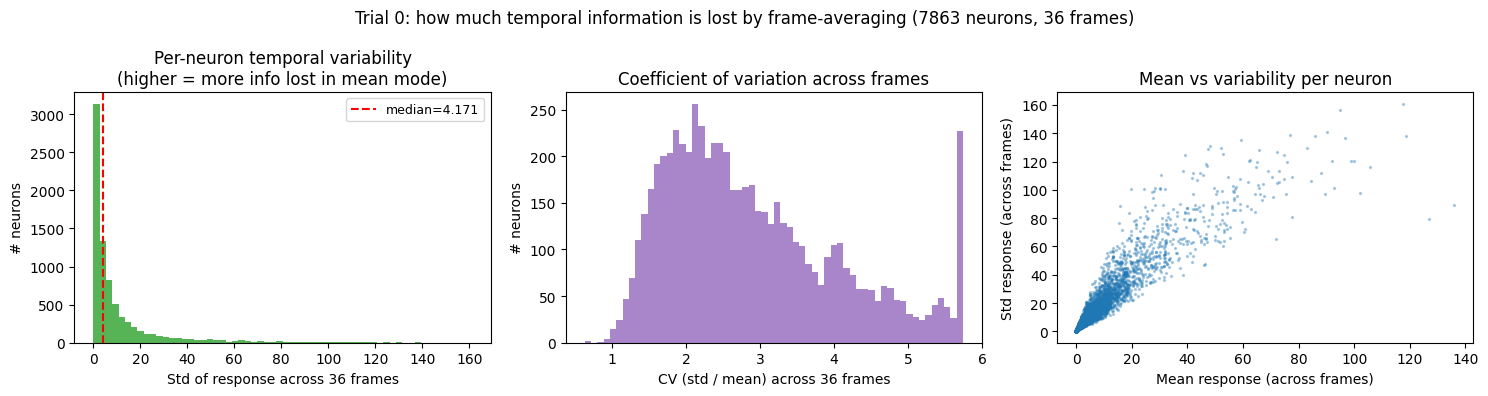


Summary: 7863 neurons, 36 frames, 324 time bins (9 bins/frame)
  Median per-neuron frame-to-frame std: 4.1705
  Max per-neuron frame-to-frame std:    161.0231
  → "per_frame" mode preserves this temporal variation;
    "mean" mode collapses it into a single average.


In [15]:
# --- Figure 4: How much temporal variation is lost by averaging ---
# For each neuron, compute the std across the 36 per-frame responses.
# Neurons with high frame-to-frame variability lose the most information in "mean" mode.

frame_std_per_neuron = np.nanstd(binned_resp, axis=0)  # (7863,)
frame_mean_per_neuron = np.nanmean(binned_resp, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(frame_std_per_neuron[frame_std_per_neuron > 0], bins=60, color="C2", alpha=0.8)
ax.set_xlabel("Std of response across 36 frames")
ax.set_ylabel("# neurons")
ax.set_title(f"Per-neuron temporal variability\n(higher = more info lost in mean mode)")
ax.axvline(np.nanmedian(frame_std_per_neuron), color="red", linestyle="--",
           label=f"median={np.nanmedian(frame_std_per_neuron):.3f}")
ax.legend(fontsize=9)

ax = axes[1]
cv = np.where(frame_mean_per_neuron > 1e-6,
              frame_std_per_neuron / frame_mean_per_neuron, 0)
ax.hist(cv[cv > 0], bins=60, color="C4", alpha=0.8)
ax.set_xlabel("CV (std / mean) across 36 frames")
ax.set_ylabel("# neurons")
ax.set_title("Coefficient of variation across frames")

ax = axes[2]
ax.scatter(frame_mean_per_neuron, frame_std_per_neuron, s=2, alpha=0.3)
ax.set_xlabel("Mean response (across frames)")
ax.set_ylabel("Std response (across frames)")
ax.set_title("Mean vs variability per neuron")

plt.suptitle(f"Trial {TRIAL_ID}: how much temporal information is lost by frame-averaging "
             f"({n_neurons} neurons, {n_frames} frames)", fontsize=12)
plt.tight_layout()
plt.show()

frac_high_var = (frame_std_per_neuron > np.nanmedian(frame_std_per_neuron)).sum()
print(f"\nSummary: {n_neurons} neurons, {n_frames} frames, {n_tbins} time bins "
      f"({n_tbins/n_frames:.0f} bins/frame)")
print(f"  Median per-neuron frame-to-frame std: {np.nanmedian(frame_std_per_neuron):.4f}")
print(f"  Max per-neuron frame-to-frame std:    {np.nanmax(frame_std_per_neuron):.4f}")
print(f'  → "per_frame" mode preserves this temporal variation;')
print(f'    "mean" mode collapses it into a single average.')